Load and combine the datasets, then restrict the dataset to residential single-family home sales to define the modeling population.

In [32]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

files = sorted(glob.glob("CRMLSSold*.csv"))
print(files)

df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df = df[(df["PropertyType"] == "Residential") &
        (df["PropertySubType"] == "SingleFamilyResidence")].copy()
df.shape
df["ClosePrice"]

['CRMLSSold202507.csv', 'CRMLSSold202508.csv', 'CRMLSSold202509.csv', 'CRMLSSold202510.csv', 'CRMLSSold202511.csv', 'CRMLSSold202512.csv']


3          1040000.0
4          2400000.0
8          1908500.0
9          1050000.0
10         5900000.0
             ...    
131876      640000.0
131878    12000000.0
131892      600000.0
131893      380000.0
131918      842000.0
Name: ClosePrice, Length: 67247, dtype: float64

In [2]:
df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

I first visually inspected a few rows to ensure the data was loaded correctly and variables look reasonable. I also examined variable types and missingness patterns to assess data usability before feature selection.

In [3]:
df.head()
df.info()
df["ClosePrice"].describe()
df.isna().mean().sort_values(ascending=False).head(15)

<class 'pandas.core.frame.DataFrame'>
Index: 67247 entries, 3 to 131918
Data columns (total 78 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 67236 non-null  object 
 1   ListAgentAOR                  67236 non-null  object 
 2   Flooring                      43478 non-null  object 
 3   ViewYN                        61001 non-null  object 
 4   WaterfrontYN                  27 non-null     object 
 5   BasementYN                    1605 non-null   object 
 6   PoolPrivateYN                 62164 non-null  object 
 7   OriginalListPrice             67116 non-null  float64
 8   ListingKey                    67247 non-null  int64  
 9   ListAgentEmail                67014 non-null  object 
 10  CloseDate                     67247 non-null  object 
 11  ClosePrice                    67247 non-null  float64
 12  ListAgentFirstName            66776 non-null  object 
 13  ListA

MiddleOrJuniorSchoolDistrict    1.000000
FireplacesTotal                 1.000000
AboveGradeFinishedArea          1.000000
TaxAnnualAmount                 1.000000
TaxYear                         1.000000
ElementarySchoolDistrict        1.000000
CoveredSpaces                   1.000000
BusinessType                    1.000000
WaterfrontYN                    0.999598
BelowGradeFinishedArea          0.992743
BasementYN                      0.976133
BuilderName                     0.955507
LotSizeDimensions               0.935596
BuildingAreaTotal               0.932830
CoBuyerAgentFirstName           0.908159
dtype: float64

I dropped columns with 50% or more missing values.

In [4]:
missing_rate = df.isna().mean()

drop_cols = missing_rate[missing_rate >= 0.5].index
print(list(drop_cols))

df = df.drop(columns=drop_cols)

['WaterfrontYN', 'BasementYN', 'CoListOfficeName', 'CoListAgentFirstName', 'CoListAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'ElementarySchool', 'BuilderName', 'SubdivisionName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']


Drop unrelated columns:
"ListPrice", "OriginalListPrice", "ListingContractDate", "ListAgentAOR", "ListAgentEmail", "ListAgentFirstName", "ListAgentLasName", "ListAgentFullName", "ListingKey", "ListingKeyNumeric", "ListingId".


In [5]:
df = df.drop(columns=["ListPrice", "OriginalListPrice", "ListingContractDate", "ListAgentAOR", "ListAgentEmail", "ListAgentFirstName",
                      "ListAgentLastName", "ListAgentFullName", "ListingKey", "ListingKeyNumeric", "ListingId"])
df

,BuyerAgentAOR,Flooring,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,UnparsedAddress,PropertyType,...,Stories,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet
3,SanDiego,NaN,False,False,2025-07-31,1040000.0,33.157973,-117.253250,1937 Elm Ridge Dr,Residential,...,2.0,Two,5318.0,NaN,False,2.0,NaN,92081,173.0,5318.0
4,PalmSprings,"Carpet,Tile",True,True,2025-07-31,2400000.0,33.803727,-116.534532,1094 E Deepwell Road,Residential,...,1.0,One,12632.0,NaN,False,2.0,NaN,92264,NaN,12632.0
8,Mlslistings,"Carpet,Laminate,Stone,Tile",True,NaN,2025-07-23,1908500.0,36.603859,-121.868261,124 Seafoam Avenue,Residential,...,NaN,NaN,3600.0,NaN,False,2.0,Other,93940,NaN,3600.0
9,PacificSouthwest,NaN,True,False,2025-07-29,1050000.0,33.151355,-117.101143,1947 Greenview Rd,Residential,...,1.0,One,17248.0,NaN,NaN,2.0,Escondido Union,92026,0.0,17248.0
10,Mlslistings,NaN,False,NaN,2025-07-31,5900000.0,37.390272,-122.110274,484 Panchita Way,Residential,...,NaN,NaN,10200.0,NaN,False,1.0,Other,94022,NaN,10200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131876,Glendale,"Tile,Wood",True,False,2025-12-05,640000.0,34.608952,-118.259648,7211 Elizabeth Lake Road,Residential,...,1.0,One,105281.0,3.0,False,3.0,Antelope Valley Union,93551,0.0,105281.0
131878,Mlslistings,"Carpet,Tile,Wood",True,NaN,2025-12-04,12000000.0,37.443497,-122.150296,535 Kingsley Avenue,Residential,...,NaN,NaN,15118.0,NaN,False,2.0,Palo Alto Unified,94301,NaN,15118.0
131892,NorthSanLuisObispo,"Carpet,Laminate",True,False,2025-12-17,600000.0,35.903719,-120.982965,70255 New Pleyto Road,Residential,...,1.0,One,20.0,3.0,False,0.0,King City Joint Union,93426,0.0,871200.0
131893,TheInlandGateway,NaN,True,False,2025-12-15,380000.0,34.261375,-117.211842,27121 Peninsula Drive,Residential,...,1.0,One,9620.0,3.0,False,1.0,Rim of the World,92352,0.0,9620.0


In [6]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["close_month"] = df["CloseDate"].dt.to_period("M")

df[["CloseDate", "close_month"]]

,CloseDate,close_month
3,2025-07-31,2025-07
4,2025-07-31,2025-07
8,2025-07-23,2025-07
9,2025-07-29,2025-07
10,2025-07-31,2025-07
...,...,...
131876,2025-12-05,2025-12
131878,2025-12-04,2025-12
131892,2025-12-17,2025-12
131893,2025-12-15,2025-12


 Remove top and bottom 0.5% of ClosePrice within the given dataframe.
 Training set:

In [7]:
last_month = df["close_month"].max()
df["close_month"].value_counts().sort_index().tail(6)
test_df = df[df["close_month"] == last_month].copy()
train_df = df[df["close_month"] < last_month].copy()

def trim_closeprice(df, price_col="ClosePrice", lower_q=0.005, upper_q=0.995):

    low = df[price_col].quantile(lower_q)
    high = df[price_col].quantile(upper_q)
    
    df_trimmed = df[
        (df[price_col] >= low) &
        (df[price_col] <= high)
    ].copy()
    
    return df_trimmed, low, high

train_trim, train_low, train_high = trim_closeprice(train_df)

print("Lower:", train_low)
print("Upper:", train_high)
print("Before:", train_df.shape)
print("After:", train_trim.shape)

Lower: 189000.0
Upper: 8801525.094999941
Before: (56792, 45)
After: (56226, 45)


Testing set:

In [8]:
test_trim, test_low, test_high = trim_closeprice(test_df)

print("Lower:", test_low)
print("Upper:", test_high)
print("Before:", test_df.shape)
print("After:", test_trim.shape)

Lower: 179000.0
Upper: 8586499.999999978
Before: (10455, 45)
After: (10350, 45)


Verify proportion of observations removed after outlier trimming.

In [9]:
print("Train removed:", 1 - len(train_trim) / len(train_df))
print("Test removed:", 1 - len(test_trim) / len(test_df))

Train removed: 0.00996619242146779
Test removed: 0.010043041606886627


Check the ClosePrice numeric integrity prior to transformation

In [22]:
train_df["ClosePrice"].dtype, train_df["ClosePrice"].head()
cp_train = pd.to_numeric(train_df["ClosePrice"], errors="coerce")
print("missing after numeric:", cp_train.isna().mean())
print("min:", cp_train.min(), "num <= 0:", (cp_train <= 0).sum())

missing after numeric: 0.0
min: 0.0 num <= 0: 1


In [21]:
test_df["ClosePrice"].dtype, test_df["ClosePrice"].head()
cp_test = pd.to_numeric(test_df["ClosePrice"], errors="coerce")
print("missing after numeric:", cp_test.isna().mean())
print("min:", cp_test.min(), "num <= 0:", (cp_test <= 0).sum())

missing after numeric: 0.0
min: 31000.0 num <= 0: 0


In [23]:
cp_train = train_df["ClosePrice"]
cp_train = cp_train[cp_train > 0]

The histograms below compare the log-transformed ClosePrice distribution before and after trimming extreme values. Trimming the top and bottom 0.5% reduces tail heaviness and results in a more symmetric distribution.

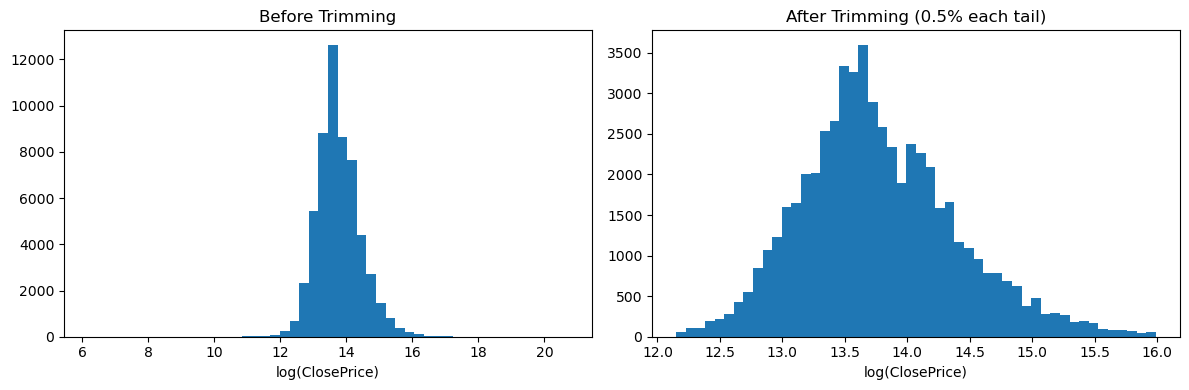

In [24]:
cp_before_train = train_df["ClosePrice"]
cp_before_train = cp_before_train[cp_before_train > 0]

cp_after_train = train_trim["ClosePrice"]
cp_after_train = cp_after_train[cp_after_train > 0]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(np.log(cp_before_train), bins=50)
axes[0].set_title("Before Trimming")
axes[0].set_xlabel("log(ClosePrice)")

axes[1].hist(np.log(cp_after_train), bins=50)
axes[1].set_title("After Trimming (0.5% each tail)")
axes[1].set_xlabel("log(ClosePrice)")

plt.tight_layout()
plt.show()

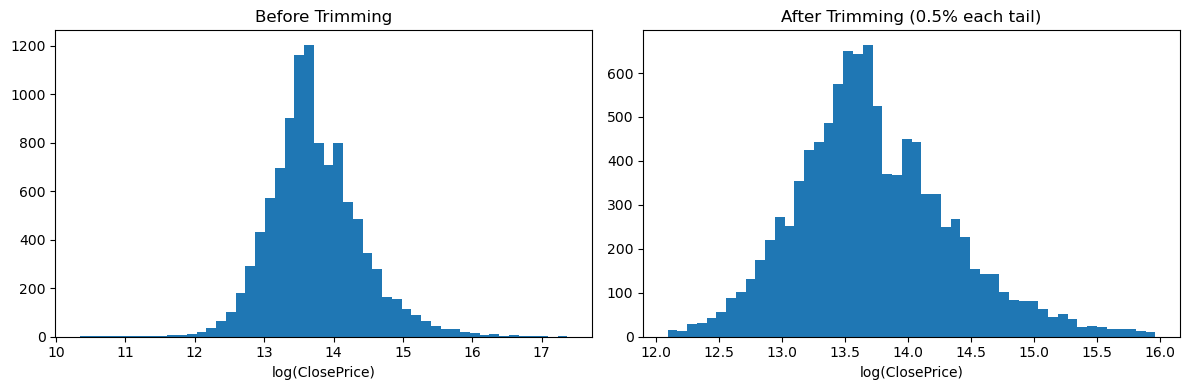

In [25]:
cp_before_test = test_df["ClosePrice"]

cp_after_test = test_trim["ClosePrice"]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(np.log(cp_before_test), bins=50)
axes[0].set_title("Before Trimming")
axes[0].set_xlabel("log(ClosePrice)")

axes[1].hist(np.log(cp_after_test), bins=50)
axes[1].set_title("After Trimming (0.5% each tail)")
axes[1].set_xlabel("log(ClosePrice)")

plt.tight_layout()
plt.show()

In [33]:
train_trim['logPrice'] = np.log(train_df['ClosePrice'])
test_trim['logPrice'] = np.log(test_df['ClosePrice'])

/Users/jenny/Desktop/IDX Exchange Intership/idx_california/california/.conda/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Some possible predictors:
1. LivingArea, BedroomsTotal, BathroomsTotalInteger, Stories, Levels, MainLevelBedrooms, GarageSpaces, ParkingTotal...
2. Latitude, Longitude, City, CountyOrParish, StateOrProvince...
3. YearBuilt, NewConstructionYN, FireplaceYN, ViewYN, PoolPrivateYN, AssociationFee...



Maybe use the median of each column to replace rest of the missing values?

In [35]:
cat_cols = train_trim.select_dtypes(include=["object", "bool"]).columns
num_cols = train_trim.select_dtypes(include=["int64", "float64"]).columns
cat_cols1 = test_trim.select_dtypes(include=["object", "bool"]).columns
num_cols1 = test_trim.select_dtypes(include=["int64", "float64"]).columns

from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy="median")
train_trim[num_cols] = num_imputer.fit_transform(train_trim[num_cols])
test_trim[num_cols] = num_imputer.fit_transform(test_trim[num_cols])

Replace the missing value in categorical columns with "Unknow". Do we need to?

In [36]:
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
train_trim[cat_cols] = cat_imputer.fit_transform(train_trim[cat_cols])
test_trim[cat_cols] = cat_imputer.fit_transform(test_trim[cat_cols])

In [62]:
train_trim = train_trim.drop(columns="close_month")
test_trim = test_trim.drop(columns="close_month")

In [63]:
train_trim.to_csv("train_trim.csv", index=False)
test_trim.to_csv("test_trim.csv", index=False)

In [64]:
train = pd.read_csv("train_trim.csv")
train

,BuyerAgentAOR,Flooring,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,UnparsedAddress,PropertyType,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,logPrice
0,SanDiego,Unknown,False,False,2025-07-31,1040000.0,33.157973,-117.253250,1937 Elm Ridge Dr,Residential,...,Two,5318.00,3.0,False,2.0,Unknown,92081,173.0,5318.0,13.854731
1,PalmSprings,"Carpet,Tile",True,True,2025-07-31,2400000.0,33.803727,-116.534532,1094 E Deepwell Road,Residential,...,One,12632.00,3.0,False,2.0,Unknown,92264,0.0,12632.0,14.690979
2,Mlslistings,"Carpet,Laminate,Stone,Tile",True,Unknown,2025-07-23,1908500.0,36.603859,-121.868261,124 Seafoam Avenue,Residential,...,Unknown,3600.00,3.0,False,2.0,Other,93940,0.0,3600.0,14.461828
3,PacificSouthwest,Unknown,True,False,2025-07-29,1050000.0,33.151355,-117.101143,1947 Greenview Rd,Residential,...,One,17248.00,3.0,Unknown,2.0,Escondido Union,92026,0.0,17248.0,13.864301
4,Mlslistings,Unknown,False,Unknown,2025-07-31,5900000.0,37.390272,-122.110274,484 Panchita Way,Residential,...,Unknown,10200.00,3.0,False,1.0,Other,94022,0.0,10200.0,15.590463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56221,CoastalMendocino,"Laminate,Tile",True,False,2025-11-26,675000.0,39.450744,-123.760617,30380 Jacobson Lane,Residential,...,Two,1.83,3.0,Unknown,2.0,Unknown,95437,0.0,79714.8,13.422468
56222,PacificWest,Unknown,False,False,2025-11-15,805000.0,34.080766,-118.203070,3527 Flora Avenue,Residential,...,One,7219.00,3.0,False,2.0,Los Angeles Unified,90031,0.0,7219.0,13.598598
56223,CitrusValley,Unknown,True,False,2025-11-21,700000.0,32.703615,-117.073444,112 S 58th Street,Residential,...,One,6900.00,6.0,False,2.0,San Diego Unified,92114,0.0,6900.0,13.458836
56224,HighDesert,Unknown,True,False,2025-11-05,215000.0,34.501814,-117.775047,19805 Pearblossom,Residential,...,One,218781.00,3.0,False,0.0,Antelope Valley Union,93544,0.0,218781.0,12.278393


In [65]:
test = pd.read_csv("test_trim.csv")
test

,BuyerAgentAOR,Flooring,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,UnparsedAddress,PropertyType,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,logPrice
0,ContraCosta,"Carpet,Tile,Wood",Unknown,False,2025-12-31,1998000.0,37.871927,-122.029871,645 Appaloosa Dr,Residential,...,One,10080.0,3.0,False,3.0,San Ramon Valley,94596,975.0,10080.0,14.507657
1,SanDiego,"Carpet,Wood",True,False,2025-12-31,2214421.0,34.150680,-118.580650,4421 Natoma Avenue,Residential,...,Two,34745.0,3.0,False,3.0,Unknown,91364,0.0,34745.0,14.610502
2,Mlslistings,Unknown,False,Unknown,2025-12-31,1200000.0,37.306405,-121.835428,2703 Apollo Drive,Residential,...,Unknown,6600.0,3.0,False,2.0,Other,95121,0.0,6600.0,13.997832
3,Mlslistings,Unknown,False,Unknown,2025-12-31,3100000.0,37.272636,-121.921351,2703 Sutro Drive,Residential,...,Unknown,8262.0,3.0,False,1.0,San Jose Unified,95124,0.0,8262.0,14.946913
4,Mlslistings,Unknown,False,Unknown,2025-12-31,2900000.0,37.303942,-121.935424,940 Arnold Way,Residential,...,Unknown,9222.0,3.0,False,2.0,Other,95128,0.0,9222.0,14.880221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10345,Mlslistings,"Carpet,Stone,Wood",True,Unknown,2025-12-01,479500.0,36.351756,-121.582590,39450 Tassajara Road,Residential,...,Unknown,1745449.0,3.0,False,0.0,Carmel Unified,93924,0.0,1745449.0,13.080499
10346,Glendale,"Tile,Wood",True,False,2025-12-05,640000.0,34.608952,-118.259648,7211 Elizabeth Lake Road,Residential,...,One,105281.0,3.0,False,3.0,Antelope Valley Union,93551,0.0,105281.0,13.369223
10347,NorthSanLuisObispo,"Carpet,Laminate",True,False,2025-12-17,600000.0,35.903719,-120.982965,70255 New Pleyto Road,Residential,...,One,20.0,3.0,False,0.0,King City Joint Union,93426,0.0,871200.0,13.304685
10348,TheInlandGateway,Unknown,True,False,2025-12-15,380000.0,34.261375,-117.211842,27121 Peninsula Drive,Residential,...,One,9620.0,3.0,False,1.0,Rim of the World,92352,0.0,9620.0,12.847927


In [66]:
train.columns

Index(['BuyerAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'DaysOnMarket', 'ListOfficeName',
       'BuyerOfficeName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode',
       'AssociationFee', 'LotSizeSquareFeet', 'logPrice'],
      dtype='object')

Linear Regression

In [67]:
y_train = train['logPrice']
y_test  = test['logPrice']
num_features = [
    'LivingArea',
    'BedroomsTotal',
    'GarageSpaces',
    'AssociationFee',
    'LotSizeArea',
]

X_train = train[num_features]
X_test  = test[num_features]


In [68]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred_log = lm.predict(X_test)

Check $R^2$

In [69]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_log)
r2

0.33204155035152305

MdAPE

In [74]:
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred_log)

MdAPE = np.median(np.abs(y_test_price - y_pred_price) / y_test_price) * 100
MdAPE

33.810368982261174

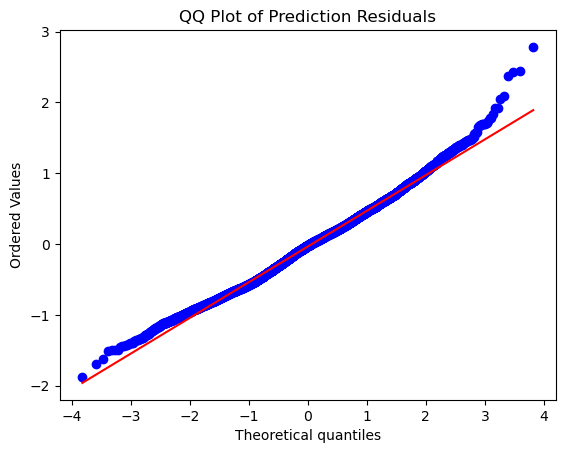

In [71]:
residuals = y_test - y_pred_log

import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Prediction Residuals")
plt.show()
